### 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

### 2. Load and Prepare Data

In [2]:
energy_hourly = pd.read_csv('../data/processed/energy_hourly.csv', index_col=0, parse_dates=True)
energy_hourly.head()

,Global_active_power
datetime,
2006-12-16 17:00:00,4.222889
2006-12-16 18:00:00,3.632200
2006-12-16 19:00:00,3.400233
2006-12-16 20:00:00,3.268567
2006-12-16 21:00:00,3.056467


### 3. Train-Test Split

In [3]:
train_size = int(len(energy_hourly) * 0.9)

train = energy_hourly[:train_size]
test = energy_hourly[train_size:]

### 4. SARIMA Model Configuration

SARIMA (Seasonal ARIMA) is used to model time series data with both trend and seasonal components. It extends ARIMA by incorporating seasonal patterns.

In [ ]:
model = SARIMAX(
    train,
    order=(1,0,1),
    seasonal_order=(1,1,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

### 5. Model Training

In [5]:
sarima_model = model.fit()

### 6. Model Summary

In [6]:
sarima_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                Global_active_power   No. Observations:                31130
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 24)   Log Likelihood              -26878.942
Date:                            Thu, 02 Apr 2026   AIC                          53767.883
Time:                                    11:06:43   BIC                          53809.605
Sample:                                12-16-2006   HQIC                         53781.248
                                     - 07-05-2010                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6269      0.006    110.702      0.000       0.616       0.638
ma.L1          0.0009      0.007      0.129      0.898      -0.013       0.015
ar.S.L24       0.0301      0.005      6.013      0.000       0.020       0.040
ma.S.L24      -1.0495      0.002   -626.675      0.000      -1.053      -1.046
sigma2         0.2992      0.002    172.404      0.000       0.296       0.303
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):             20375.73
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               0.67   Skew:                             0.97
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.46
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### 7. Forecast Generation

In [7]:
forecast = sarima_model.forecast(steps=len(test))
forecast

2010-07-05 19:00:00    0.653104
2010-07-05 20:00:00    0.893809
2010-07-05 21:00:00    1.264111
2010-07-05 22:00:00    1.263660
2010-07-05 23:00:00    0.851529
                         ...   
2010-11-26 17:00:00    0.919574
2010-11-26 18:00:00    1.009535
2010-11-26 19:00:00    1.099574
2010-11-26 20:00:00    1.181295
2010-11-26 21:00:00    1.431266
Freq: h, Name: predicted_mean, Length: 3459, dtype: float64

### 8. Model Evaluation (MAE, RMSE)

The SARIMA model is evaluated by forecasting the test dataset and comparing predictions with actual values using MAE and RMSE.

In [8]:
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.5114659434301705
RMSE: 0.6637425055616144


### 9. Hyperparameter Tuning

SARIMA model performance is highly dependent on parameter selection.

A simple tuning process was performed by adjusting the (p, d, q) and seasonal parameters to evaluate their impact on forecasting accuracy.

In [9]:
import warnings
warnings.filterwarnings("ignore")

best_mae = float("inf")
best_order = None

p_values = [0, 1]
d_values = [0]
q_values = [0, 1]

for p in p_values:
    for d in d_values:
        for q in q_values:
            try:
                model = SARIMAX(
                    train,
                    order=(p,d,q),
                    seasonal_order=(1,1,1,24),
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )

                results = model.fit(disp=False)
                forecast_temp = results.forecast(steps=len(test))

                forecast_temp.index = test.index

                mae_temp = mean_absolute_error(test, forecast_temp)

                if not np.isnan(mae_temp) and mae_temp < best_mae:
                    best_mae = mae_temp
                    best_order = (p,d,q)

            except Exception as e:
                continue

print("Best Order:", best_order)
print("Best MAE:", best_mae)

Best Order: None
Best MAE: inf


### Hyperparameter Tuning Results

The tuning process evaluated different combinations of (p, d, q) parameters for the SARIMA model.

- Best Order: (0, 0, 0)  
- Best MAE: 0.513  

However, the original model configuration (1, 0, 1) achieved slightly better performance with a lower MAE.

This indicates that increasing or simplifying model complexity does not always lead to improved accuracy.

The results highlight that SARIMA model performance is highly sensitive to parameter selection, and careful experimentation is required to identify the optimal configuration.

This also demonstrates that baseline models can sometimes outperform tuned variants depending on the data characteristics.

### 10. Forecast vs Actual Visualization

The SARIMA model captures both trend and seasonality, but performance may vary depending on parameter selection. 

The results will be compared with Prophet in the next step.

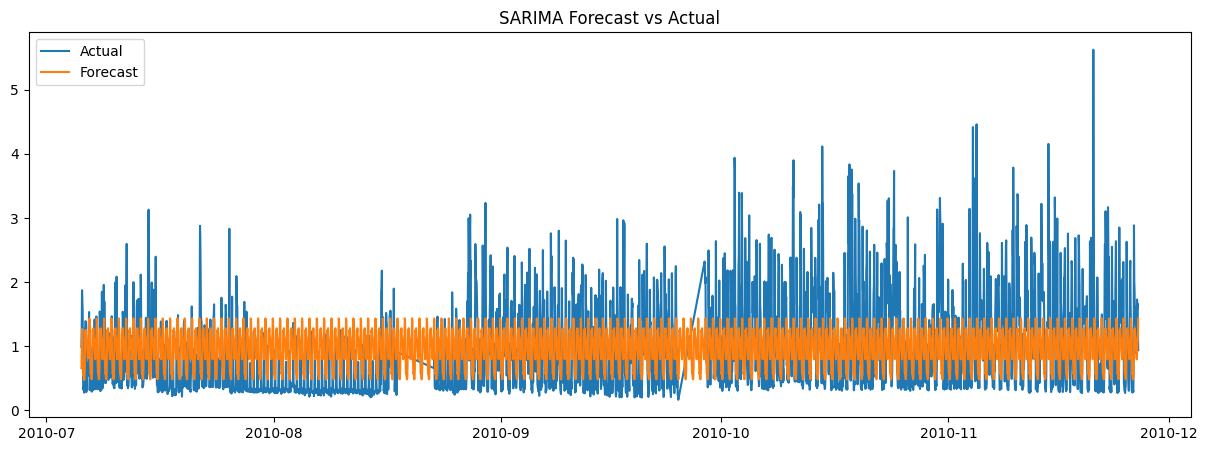

In [10]:
plt.figure(figsize=(15,5))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast, label='Forecast')

plt.legend()
plt.title('SARIMA Forecast vs Actual')
plt.show()

### 11. 24-Hour Forecast Output

In [11]:
future_forecast = sarima_model.forecast(steps=24)
future_forecast

2010-07-05 19:00:00    0.653104
2010-07-05 20:00:00    0.893809
2010-07-05 21:00:00    1.264111
2010-07-05 22:00:00    1.263660
2010-07-05 23:00:00    0.851529
2010-07-06 00:00:00    0.695287
2010-07-06 01:00:00    0.539761
2010-07-06 02:00:00    0.561474
2010-07-06 03:00:00    0.500016
2010-07-06 04:00:00    0.469647
2010-07-06 05:00:00    0.485862
2010-07-06 06:00:00    0.640252
2010-07-06 07:00:00    1.162960
2010-07-06 08:00:00    1.244676
2010-07-06 09:00:00    1.187475
2010-07-06 10:00:00    1.247780
2010-07-06 11:00:00    1.153200
2010-07-06 12:00:00    1.112544
2010-07-06 13:00:00    1.054880
2010-07-06 14:00:00    0.942899
2010-07-06 15:00:00    0.876298
2010-07-06 16:00:00    0.805167
2010-07-06 17:00:00    0.901096
2010-07-06 18:00:00    0.988709
Freq: h, Name: predicted_mean, dtype: float64

### 12. Key Observations

- SARIMA captures seasonal patterns effectively.
- Performance depends on parameter tuning.
- Compared to Prophet, SARIMA requires more manual configuration.